<a href="https://colab.research.google.com/github/KamilEjaz890/Anomaly-Detection/blob/main/Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub -q
import kagglehub

# NASA C-MAPSS dataset (mirrored on Kaggle)
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
print("Dataset path:", path)

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
Dataset path: /kaggle/input/nasa-cmaps


In [2]:
import pandas as pd
import numpy as np

# Column names: dataset mein header nahi hai, so manually define karte hain
index_names = ['unit_number', 'time_in_cycles']
setting_names = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']
sensor_names = [f'sensor_measurement_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# Train data load
train = pd.read_csv(f"{path}/CMaps/train_FD001.txt", sep=r'\s+', header=None, names=col_names)

# Test data load
test = pd.read_csv(f"{path}/CMaps/test_FD001.txt", sep=r'\s+', header=None, names=col_names)

# Ground truth RUL for test set
rul_true = pd.read_csv(f"{path}/CMaps/RUL_FD001.txt", sep=r'\s+', header=None, names=['RUL'])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("RUL truth shape:", rul_true.shape)
train.head()

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL truth shape: (100, 1)


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,...,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
train.info()
print("\nUnique engines in train:", train['unit_number'].nunique())
print("Cycles per engine (train) - stats:")
print(train.groupby('unit_number')['time_in_cycles'].max().describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            20631 non-null  int64  
 1   time_in_cycles         20631 non-null  int64  
 2   operational_setting_1  20631 non-null  float64
 3   operational_setting_2  20631 non-null  float64
 4   operational_setting_3  20631 non-null  float64
 5   sensor_measurement_1   20631 non-null  float64
 6   sensor_measurement_2   20631 non-null  float64
 7   sensor_measurement_3   20631 non-null  float64
 8   sensor_measurement_4   20631 non-null  float64
 9   sensor_measurement_5   20631 non-null  float64
 10  sensor_measurement_6   20631 non-null  float64
 11  sensor_measurement_7   20631 non-null  float64
 12  sensor_measurement_8   20631 non-null  float64
 13  sensor_measurement_9   20631 non-null  float64
 14  sensor_measurement_10  20631 non-null  float64
 15  se

In [4]:
# Har engine ke liye max cycle nikaalo (jahan failure hua)
max_cycle = train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

# Train data mein merge karo
train = train.merge(max_cycle, on='unit_number', how='left')

# RUL = max_cycle - current cycle
train['RUL'] = train['max_cycle'] - train['time_in_cycles']
train.drop('max_cycle', axis=1, inplace=True)

train[['unit_number', 'time_in_cycles', 'RUL']].head(10)

,unit_number,time_in_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


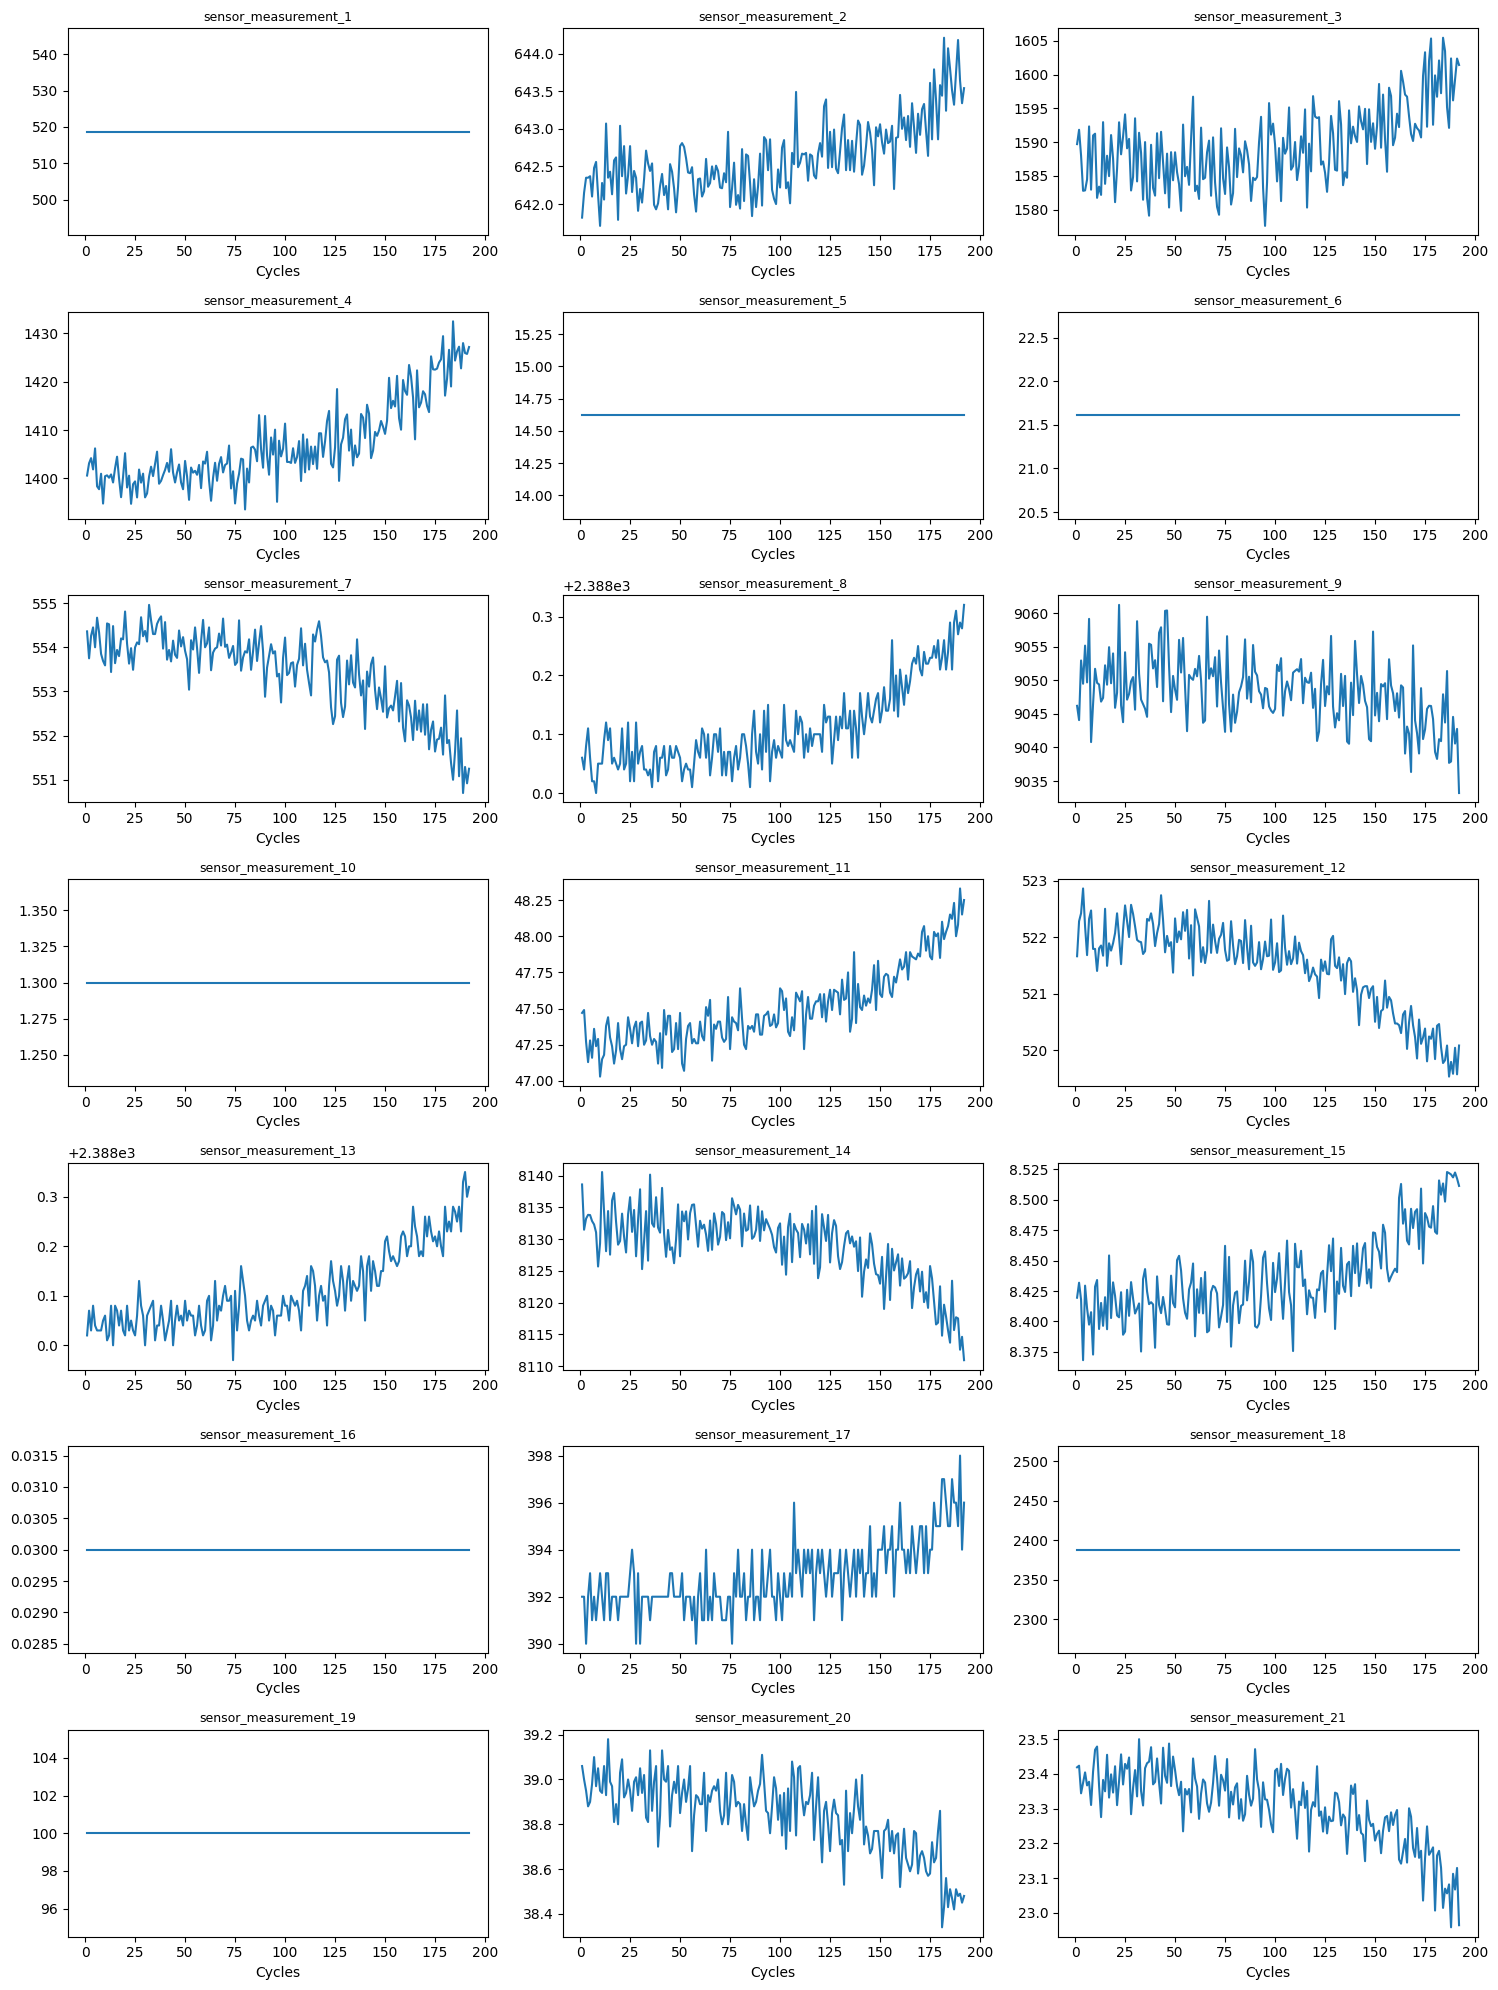

In [5]:
import matplotlib.pyplot as plt

# Ek engine choose karo (unit 1) aur uske sensors ka trend dekho
engine_1 = train[train['unit_number'] == 1]

fig, axes = plt.subplots(7, 3, figsize=(15, 20))
axes = axes.flatten()

for i, sensor in enumerate(sensor_names):
    axes[i].plot(engine_1['time_in_cycles'], engine_1[sensor])
    axes[i].set_title(sensor, fontsize=9)
    axes[i].set_xlabel('Cycles')

plt.tight_layout()
plt.show()

In [6]:
# Flat sensors jo koi signal nahi de rahe
drop_sensors = ['sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6',
                 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18',
                 'sensor_measurement_19']

# Operational settings bhi drop kar sakte hain FD001 mein (single condition hai, no variation)
drop_settings = ['operational_setting_1', 'operational_setting_2', 'operational_setting_3']

train_clean = train.drop(columns=drop_sensors + drop_settings)
test_clean = test.drop(columns=drop_sensors + drop_settings)

print("Train clean shape:", train_clean.shape)
train_clean.head()

Train clean shape: (20631, 17)


,unit_number,time_in_cycles,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_17,sensor_measurement_20,sensor_measurement_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [7]:
useful_sensors = [c for c in train_clean.columns if 'sensor' in c]

correlations = train_clean[useful_sensors + ['RUL']].corr()['RUL'].sort_values()
print(correlations)

sensor_measurement_11   -0.696228
sensor_measurement_4    -0.678948
sensor_measurement_15   -0.642667
sensor_measurement_2    -0.606484
sensor_measurement_17   -0.606154
sensor_measurement_3    -0.584520
sensor_measurement_8    -0.563968
sensor_measurement_13   -0.562569
sensor_measurement_9    -0.390102
sensor_measurement_14   -0.306769
sensor_measurement_20    0.629428
sensor_measurement_21    0.635662
sensor_measurement_7     0.657223
sensor_measurement_12    0.671983
RUL                      1.000000
Name: RUL, dtype: float64


In [8]:
RUL_CAP = 125
train_clean['RUL'] = train_clean['RUL'].clip(upper=RUL_CAP)

train_clean[['unit_number', 'time_in_cycles', 'RUL']].head(10)

,unit_number,time_in_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


In [9]:
sensor_cols = [c for c in train_clean.columns if 'sensor' in c]
window = 5

def add_rolling_features(df, sensor_cols, window):
    df = df.sort_values(['unit_number', 'time_in_cycles'])
    for col in sensor_cols:
        df[f'{col}_rollmean'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{col}_rollstd'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

train_feat = add_rolling_features(train_clean, sensor_cols, window)
test_feat = add_rolling_features(test_clean, sensor_cols, window)

print("Train features shape:", train_feat.shape)
train_feat.head()

Train features shape: (20631, 45)


,unit_number,time_in_cycles,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_11,sensor_measurement_12,...,sensor_measurement_14_rollmean,sensor_measurement_14_rollstd,sensor_measurement_15_rollmean,sensor_measurement_15_rollstd,sensor_measurement_17_rollmean,sensor_measurement_17_rollstd,sensor_measurement_20_rollmean,sensor_measurement_20_rollstd,sensor_measurement_21_rollmean,sensor_measurement_21_rollstd
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


In [10]:
from sklearn.model_selection import train_test_split

unique_units = train_feat['unit_number'].unique()
train_units, val_units = train_test_split(unique_units, test_size=0.2, random_state=42)

train_split = train_feat[train_feat['unit_number'].isin(train_units)]
val_split = train_feat[train_feat['unit_number'].isin(val_units)]

print(f"Train engines: {len(train_units)}, Val engines: {len(val_units)}")
print(f"Train rows: {train_split.shape[0]}, Val rows: {val_split.shape[0]}")

Train engines: 80, Val engines: 20
Train rows: 16561, Val rows: 4070


In [11]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in train_split.columns if c not in ['unit_number', 'time_in_cycles', 'RUL']]

X_train = train_split[feature_cols]
y_train = train_split['RUL']
X_val = val_split[feature_cols]
y_val = val_split['RUL']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled shape:", X_train_scaled.shape)
print("Feature count:", len(feature_cols))

X_train_scaled shape: (16561, 42)
Feature count: 42


In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_val_scaled)

mae = mean_absolute_error(y_val, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2 = r2_score(y_val, y_pred_rf)

print(f"MAE: {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²: {r2:.3f}")


MAE: 11.55 cycles
RMSE: 16.43 cycles
R²: 0.845


In [13]:
!pip install xgboost -q
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                    random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_val_scaled)

mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)

print(f"XGBoost - MAE: {mae_xgb:.2f}, RMSE: {rmse_xgb:.2f}, R²: {r2_xgb:.3f}")

XGBoost - MAE: 11.76, RMSE: 16.68, R²: 0.840


In [14]:
# Andrew Ng approach: sirf "normal" (healthy) data se Gaussian fit karo
# Healthy = jab RUL zyada hai (engine abhi degrade nahi hua)
normal_mask = train_split['RUL'] >= 100  # top-of-health cycles
X_normal = train_split[normal_mask][feature_cols]

X_normal_scaled = scaler.transform(X_normal)  # same scaler jo pehle fit kiya tha
print("Normal samples for fitting Gaussian:", X_normal_scaled.shape)

Normal samples for fitting Gaussian: (8561, 42)


In [15]:
from scipy.stats import multivariate_normal

mu = np.mean(X_normal_scaled, axis=0)
sigma = np.cov(X_normal_scaled, rowvar=False)

# Regularization: covariance matrix singular na ho (numerical stability)
sigma += np.eye(sigma.shape[0]) * 1e-6

print("Mean vector shape:", mu.shape)
print("Covariance matrix shape:", sigma.shape)

Mean vector shape: (42,)
Covariance matrix shape: (42, 42)


In [16]:
gaussian = multivariate_normal(mean=mu, cov=sigma, allow_singular=True)

p_val = gaussian.pdf(X_val_scaled)

print("p(x) stats on validation set:")
print(pd.Series(p_val).describe())

p(x) stats on validation set:
count    4.070000e+03
mean     1.257311e-10
std      1.733021e-09
min      8.771463e-88
25%      1.461755e-16
50%      5.913818e-14
75%      3.182795e-12
max      8.050015e-08
dtype: float64


In [17]:
# RUL < 20 cycles = "anomaly" (maintenance ki zaroorat, failure ke paas)
ANOMALY_THRESHOLD = 20
y_val_anomaly = (val_split['RUL'].values < ANOMALY_THRESHOLD).astype(int)

print("Anomaly count in validation set:", y_val_anomaly.sum(), "out of", len(y_val_anomaly))
print("Anomaly %:", round(y_val_anomaly.mean()*100, 2))

Anomaly count in validation set: 400 out of 4070
Anomaly %: 9.83


In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score

def select_epsilon(p_val, y_val_anomaly):
    best_epsilon = 0
    best_f1 = 0

    # p(x) ki range mein log-scale steps try karo (kyunki values bohot chhoti hain)
    epsilons = np.percentile(p_val, np.linspace(0.1, 20, 100))

    for eps in epsilons:
        preds = (p_val < eps).astype(int)
        f1 = f1_score(y_val_anomaly, preds)
        if f1 > best_f1:
            best_f1 = f1
            best_epsilon = eps

    return best_epsilon, best_f1

best_eps, best_f1 = select_epsilon(p_val, y_val_anomaly)
print(f"Best epsilon: {best_eps:.2e}")
print(f"Best F1-score: {best_f1:.3f}")

Best epsilon: 2.19e-18
Best F1-score: 0.565


In [19]:
y_pred_anomaly = (p_val < best_eps).astype(int)

precision = precision_score(y_val_anomaly, y_pred_anomaly)
recall = recall_score(y_val_anomaly, y_pred_anomaly)
f1 = f1_score(y_val_anomaly, y_pred_anomaly)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Precision: 0.456
Recall: 0.743
F1-score: 0.565


In [20]:
from sklearn.ensemble import IsolationForest

# contamination = expected anomaly proportion (humne validation mein dekha tha ~y_val_anomaly.mean())
contamination_rate = y_val_anomaly.mean()

iso_forest = IsolationForest(n_estimators=200, contamination=contamination_rate,
                               random_state=42, n_jobs=-1)
iso_forest.fit(X_train_scaled)

# Predict: -1 = anomaly, 1 = normal (sklearn convention)
iso_pred_raw = iso_forest.predict(X_val_scaled)
iso_pred = (iso_pred_raw == -1).astype(int)  # convert to 0/1 (1 = anomaly)

iso_precision = precision_score(y_val_anomaly, iso_pred)
iso_recall = recall_score(y_val_anomaly, iso_pred)
iso_f1 = f1_score(y_val_anomaly, iso_pred)

print(f"Isolation Forest - Precision: {iso_precision:.3f}, Recall: {iso_recall:.3f}, F1: {iso_f1:.3f}")

Isolation Forest - Precision: 0.792, Recall: 0.760, F1: 0.776


In [21]:
comparison = pd.DataFrame({
    'Method': ['Gaussian (Andrew Ng)', 'Isolation Forest'],
    'Precision': [precision, iso_precision],
    'Recall': [recall, iso_recall],
    'F1-Score': [f1, iso_f1]
})
print(comparison.to_string(index=False))

              Method  Precision  Recall  F1-Score
Gaussian (Andrew Ng)   0.456221  0.7425  0.565176
    Isolation Forest   0.791667  0.7600  0.775510


In [22]:
val_split = val_split.copy()
val_split['true_anomaly'] = y_val_anomaly
val_split['gaussian_pred'] = y_pred_anomaly
val_split['isoforest_pred'] = iso_pred
val_split['p_x'] = p_val

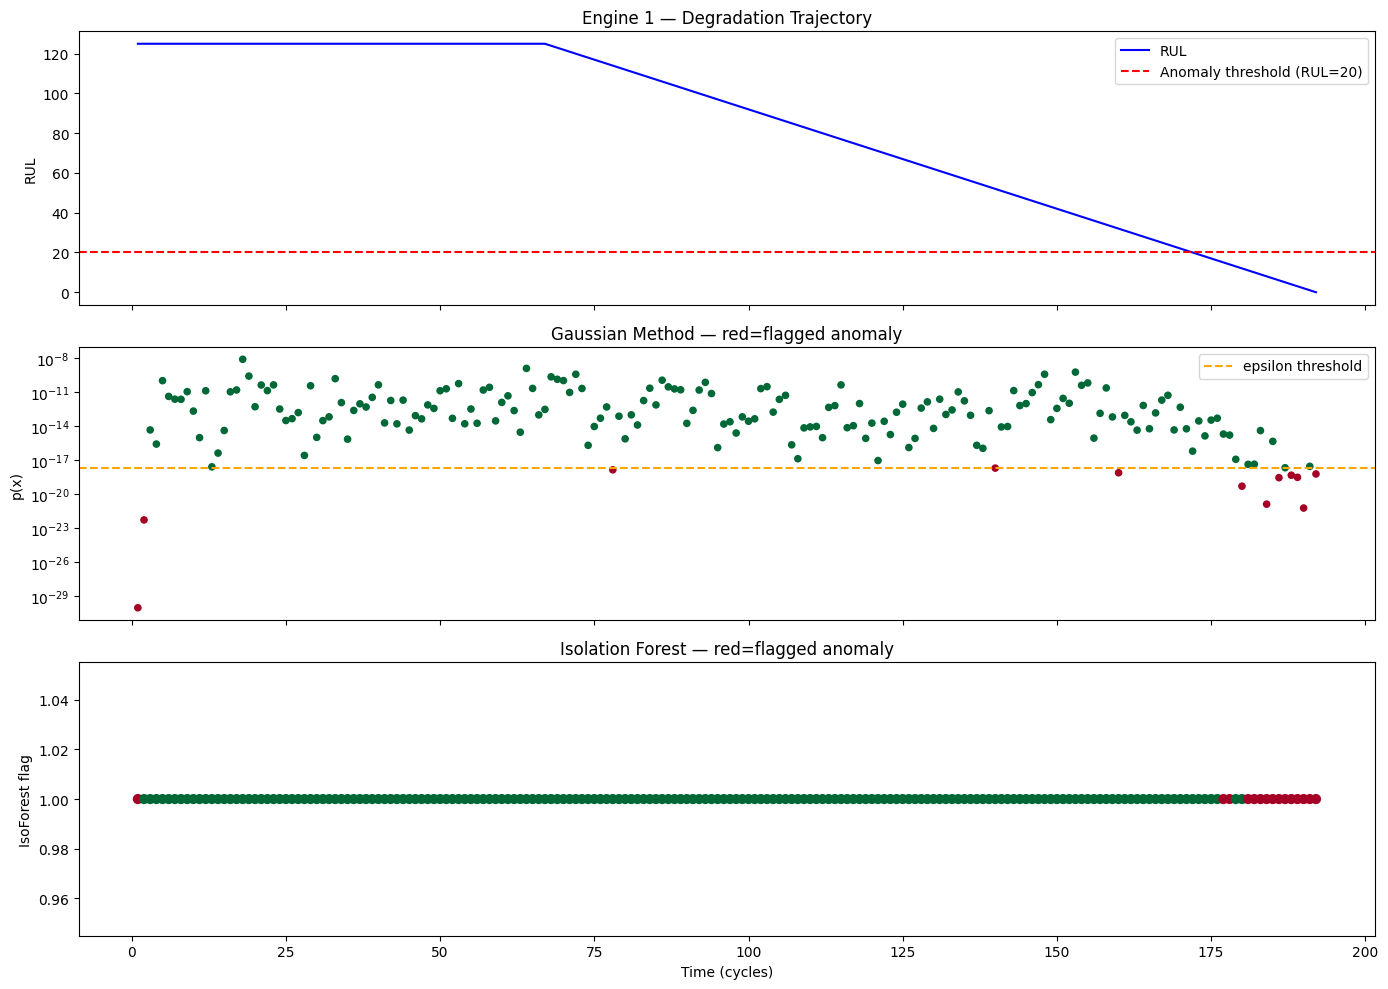

In [23]:
sample_unit = val_split['unit_number'].unique()[0]
engine_data = val_split[val_split['unit_number'] == sample_unit].sort_values('time_in_cycles')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: RUL over time with true anomaly zone
axes[0].plot(engine_data['time_in_cycles'], engine_data['RUL'], color='blue', label='RUL')
axes[0].axhline(y=20, color='red', linestyle='--', label='Anomaly threshold (RUL=20)')
axes[0].set_ylabel('RUL')
axes[0].legend()
axes[0].set_title(f'Engine {sample_unit} — Degradation Trajectory')

# Plot 2: Gaussian method predictions
axes[1].scatter(engine_data['time_in_cycles'], engine_data['p_x'],
                 c=engine_data['gaussian_pred'], cmap='RdYlGn_r', s=20)
axes[1].axhline(y=best_eps, color='orange', linestyle='--', label='epsilon threshold')
axes[1].set_ylabel('p(x)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Gaussian Method — red=flagged anomaly')

# Plot 3: Isolation Forest predictions
axes[2].scatter(engine_data['time_in_cycles'], [1]*len(engine_data),
                 c=engine_data['isoforest_pred'], cmap='RdYlGn_r', s=40)
axes[2].set_ylabel('IsoForest flag')
axes[2].set_xlabel('Time (cycles)')
axes[2].set_title('Isolation Forest — red=flagged anomaly')

plt.tight_layout()
plt.show()

In [28]:
def predict_anomaly(new_readings_df, model_type='both'):
    """
    new_readings_df: pandas DataFrame with same raw columns as train
                      (unit_number, time_in_cycles, sensor_measurement_1-21)
                      ideally with a few previous cycles too, so rolling features
                      can be computed properly (window=5)
    """
    # Step 1: same cleaning — drop flat sensors + operational settings
    df = new_readings_df.drop(columns=[c for c in drop_sensors + drop_settings if c in new_readings_df.columns])

    # Step 2: same rolling feature engineering
    df = add_rolling_features(df, sensor_cols, window)

    # Step 3: take the LATEST cycle only (the point we actually want to classify)
    latest = df.sort_values('time_in_cycles').iloc[[-1]]
    X_new = latest[feature_cols]

    # Step 4: scale using the SAME fitted scaler (never refit on new data)
    X_new_scaled = scaler.transform(X_new)

    result = {}

    if model_type in ('gaussian', 'both'):
        p_new = gaussian.pdf(X_new_scaled)[0]
        result['gaussian_p(x)'] = p_new
        result['gaussian_anomaly'] = bool(p_new < best_eps)

    if model_type in ('isoforest', 'both'):
        iso_raw = iso_forest.predict(X_new_scaled)[0]
        result['isoforest_anomaly'] = bool(iso_raw == -1)

    return result